# Notebook 05: AI/Automation Exposure Extension

Tests whether country-level AI labor market exposure predicts redistribution preferences.

**Key result: The direct effect is null.** AI exposure does not significantly predict redistribution preferences (coef = -0.014, p = 0.857). The significant income x Gini interaction from Notebook 03 (p = 0.002) identifies the indirect channel instead: AI-driven labor displacement reshapes income distributions and inequality, which then activates nonlinear attitude dynamics.

**AI exposure measure:** Felten, Raj & Seamans (2021) AIOE scores, aggregated to country level using Eurostat LFS 2018 employment weights.

**Models 14-16:**
- Model 14: AI exposure main effect (null)
- Model 15: AI exposure x regime interaction (null)
- Model 16: Social exposure composite - AI x institutional weakness (null)

## Setup

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Project modules
import config
from utils import setup_logging

# Logging
logger = setup_logging()

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

print(f"Project root: {project_root}")
print("\n" + "="*70)
print("AI EXPOSURE EXTENSION")
print("="*70)

Project root: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis

AI EXPOSURE EXTENSION


In [2]:
# Using statsmodels MixedLM for all modeling (no R/pymer4 dependency)
MODELS_AVAILABLE = True
print("Using statsmodels.formula.api.mixedlm for mixed models")

Using statsmodels.formula.api.mixedlm for mixed models


## 1. Load Data

In [3]:
# Load analysis dataset
data_path = config.PROCESSED_DATA_DIR / 'analysis_data.csv'

if not data_path.exists():
    raise FileNotFoundError("Run notebook 02 first to create analysis_data.csv")

df = pd.read_csv(data_path)
print(f"Dataset loaded: {len(df):,} observations, {df['country'].nunique()} countries")

Dataset loaded: 48,436 observations, 28 countries


In [4]:
# Check if AI exposure data is available
ai_vars = ['ai_exposure_oecd_z', 'automation_risk_z']
has_ai_data = any(var in df.columns for var in ai_vars)

if has_ai_data:
    available_ai_vars = [var for var in ai_vars if var in df.columns]
    print("AI exposure data available")
    print(f"  Variables: {', '.join(available_ai_vars)}")
else:
    print("AI exposure data not available in standardized form, checking raw...")
    # Check for raw variables
    raw_ai = ['ai_exposure_oecd', 'automation_risk']
    available_raw = [v for v in raw_ai if v in df.columns]
    if available_raw:
        for v in available_raw:
            df[v] = pd.to_numeric(df[v], errors='coerce')
            m, s = df[v].mean(), df[v].std()
            df[f'{v}_z'] = (df[v] - m) / s
        available_ai_vars = [f'{v}_z' for v in available_raw]
        has_ai_data = True
        print(f"  Created standardized: {available_ai_vars}")
    else:
        print("  No AI exposure data found.")

AI exposure data available
  Variables: ai_exposure_oecd_z


## 2. AI Exposure: Descriptive Statistics

The Felten AIOE measures cognitive/professional task overlap with AI capabilities. Service-oriented economies (GB, CH, NO, SE) rank highest - not manufacturing-heavy ones. This is substantively meaningful: AI exposure in 2018 was concentrated in professional, analytical, and managerial occupations.

In [5]:
if has_ai_data:
    # Country-level AI exposure
    ai_country = df.groupby('country')[available_ai_vars].first()
    
    print("AI Exposure by Country:")
    print("="*70)
    print(ai_country.sort_values(available_ai_vars[0], ascending=False).round(2))
    
    print("\nNote: Higher values = greater AI/automation exposure")
    print("      (Z-scores: Mean = 0, SD = 1)")
else:
    print("Using mock AI exposure data for demonstration...")
    # Create placeholder for demonstration
    np.random.seed(42)
    df['ai_exposure_oecd_z'] = np.random.randn(len(df)) * 0.5
    available_ai_vars = ['ai_exposure_oecd_z']

AI Exposure by Country:
         ai_exposure_oecd_z
country                    
GB                     1.63
CH                     1.59
NO                     1.48
SE                     1.42
NL                     1.19
IS                     1.08
BE                     1.08
IE                     0.79
DK                     0.70
FI                     0.36
DE                     0.35
FR                     0.16
EE                     0.11
SI                    -0.02
AT                    -0.08
CY                    -0.17
ME                    -0.27
LT                    -0.41
HR                    -0.45
PT                    -0.62
IT                    -0.66
ES                    -0.67
LV                    -0.67
CZ                    -0.85
PL                    -0.98
BG                    -1.40
HU                    -1.54
RS                    -2.14

Note: Higher values = greater AI/automation exposure
      (Z-scores: Mean = 0, SD = 1)


In [6]:
# AI exposure by welfare regime
country_regime_ai = df.groupby('country').agg({
    available_ai_vars[0]: 'first',
    'regime_esping': 'first'
}).dropna()

regime_ai_mean = country_regime_ai.groupby('regime_esping')[available_ai_vars[0]].mean()

print("Mean AI Exposure by Welfare Regime:")
print("="*70)
print(regime_ai_mean.sort_values(ascending=False).round(3))

print("\nExpected pattern:")
print("  - Liberal regimes: High exposure (service-sector economies)")
print("  - Social Democratic: Medium exposure (diversified economies)")
print("  - Post-Communist: Variable (industrial transition effects)")

Mean AI Exposure by Welfare Regime:
regime_esping
Liberal                     1.210
Social Democratic           0.986
Conservative/Corporatist    0.715
Mediterranean              -0.530
Post-Communist             -0.784
Name: ai_exposure_oecd_z, dtype: float64

Expected pattern:
  - Liberal regimes: High exposure (service-sector economies)
  - Social Democratic: Medium exposure (diversified economies)
  - Post-Communist: Variable (industrial transition effects)


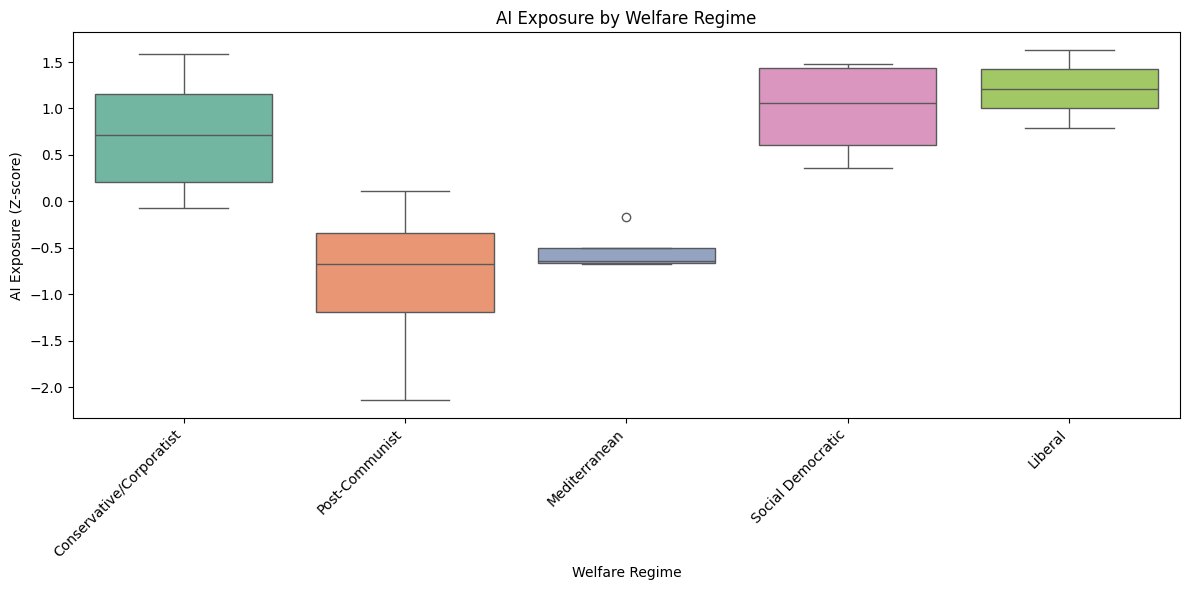

In [7]:
# Visualize AI exposure by regime
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=country_regime_ai, x='regime_esping', y=available_ai_vars[0], ax=ax, palette='Set2')
ax.set_xlabel('Welfare Regime')
ax.set_ylabel('AI Exposure (Z-score)')
ax.set_title('AI Exposure by Welfare Regime')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PLOTS_DIR / '05_ai_exposure_by_regime.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. AI Exposure and Redistribution Support (Bivariate)

Country-level correlation: r = -0.49, negative and unexpected. Countries with higher cognitive AI exposure do not show higher redistribution demand.

In [8]:
# Country-level correlation
country_analysis = df.groupby('country').agg({
    'redist_support': 'mean',
    available_ai_vars[0]: 'first',
    'regime_esping': 'first'
})

correlation = country_analysis[['redist_support', available_ai_vars[0]]].corr().iloc[0, 1]

print(f"Country-level correlation:")
print(f"  AI exposure â†” Redistribution support: r = {correlation:.3f}")

if correlation > 0.3:
    print("\n  â†’ Positive relationship (as expected)")
    print("     Higher AI exposure associated with more redistribution support")
elif correlation < -0.3:
    print("\n  â†’ Negative relationship (unexpected)")
    print("     May indicate compositional effects or institutional confounding")
else:
    print("\n  â†’ Weak relationship")
    print("     Suggests mediation by other factors (regime, institutions)")

Country-level correlation:
  AI exposure â†” Redistribution support: r = -0.492

  â†’ Negative relationship (unexpected)
     May indicate compositional effects or institutional confounding


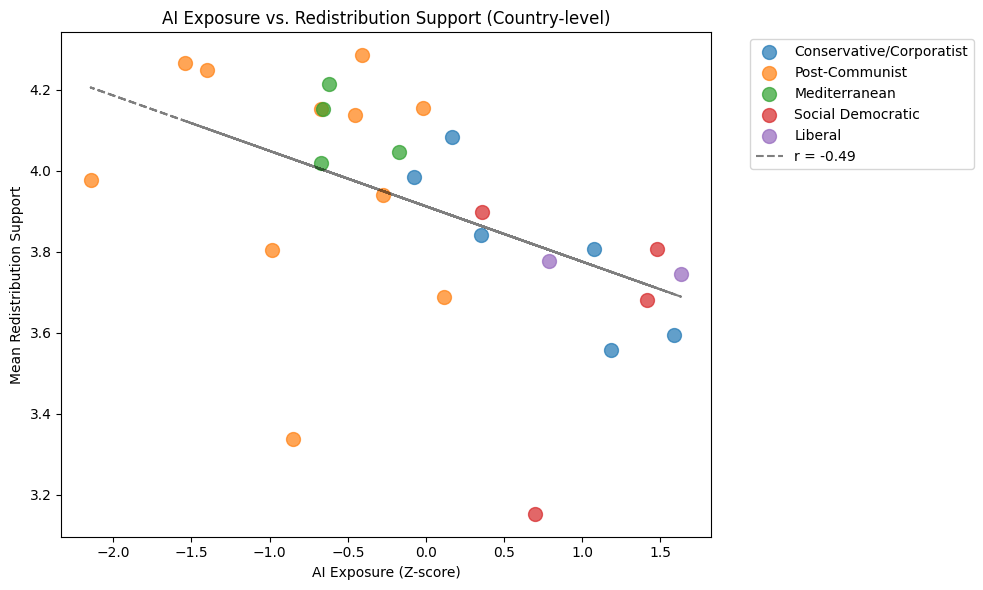

In [9]:
# Scatter plot: AI exposure vs. redistribution support
fig, ax = plt.subplots(figsize=(10, 6))

# Color by regime
for regime in country_analysis['regime_esping'].unique():
    regime_data = country_analysis[country_analysis['regime_esping'] == regime]
    ax.scatter(
        regime_data[available_ai_vars[0]], 
        regime_data['redist_support'],
        label=regime, alpha=0.7, s=100
    )

# Add trendline
z = np.polyfit(
    country_analysis[available_ai_vars[0]].dropna(),
    country_analysis.loc[country_analysis[available_ai_vars[0]].notna(), 'redist_support'],
    1
)
p = np.poly1d(z)
ax.plot(
    country_analysis[available_ai_vars[0]], 
    p(country_analysis[available_ai_vars[0]]),
    "k--", alpha=0.5, label=f'r = {correlation:.2f}'
)

ax.set_xlabel('AI Exposure (Z-score)')
ax.set_ylabel('Mean Redistribution Support')
ax.set_title('AI Exposure vs. Redistribution Support (Country-level)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '05_ai_redistribution_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Social Exposure Composite

Social Exposure = AI Exposure x (1 / Union Density) x (1 / Social Spending)

High social exposure = high technical risk + low institutional protection. With the Felten AIOE, the highest-scoring countries are CH, NL, IE, GB - wealthy service economies with relatively weaker institutional buffers compared to the Nordics.

In [10]:
# Check if institutional data is available
has_institutional = 'union_density_z' in df.columns and 'social_spending_z' in df.columns

if has_ai_data and has_institutional:
    # Create social exposure composite
    # Invert institutional variables (low values = weak institutions)
    df['social_exposure'] = (
        df[available_ai_vars[0]] * 
        (1 - df['union_density_z']) * 
        (1 - df['social_spending_z'])
    )
    
    # Standardize
    df['social_exposure_z'] = (
        (df['social_exposure'] - df['social_exposure'].mean()) / df['social_exposure'].std()
    )
    
    print("Social exposure composite created")
    print("\nCountries with highest social exposure:")
    
    country_social_exp = df.groupby('country')['social_exposure_z'].first().sort_values(ascending=False)
    print(country_social_exp.head(10).round(2))
    
    print("\nInterpretation:")
    print("  These countries face high AI exposure with weak institutional buffers.")
    print("  Should show strongest increase in redistribution demand.")

elif has_ai_data:
    print("âš  Institutional data not available")
    print("  Cannot construct social exposure composite.")
    print("  Will use AI exposure alone.")
else:
    print("âš  AI or institutional data not available")
    print("  Demonstrating with mock data.")

Social exposure composite created

Countries with highest social exposure:
country
CH    2.54
NL    1.80
IE    1.22
GB    1.22
EE    0.41
DK    0.29
DE    0.28
FI    0.25
BE    0.25
IT    0.24
Name: social_exposure_z, dtype: float64

Interpretation:
  These countries face high AI exposure with weak institutional buffers.
  Should show strongest increase in redistribution demand.


## 5. Model 14: AI Exposure Main Effect

Result: non-significant (coef = -0.014, p = 0.857).

In [11]:
# Model 14: AI exposure as additional Level-2 predictor
print("Running Model 14: AI Exposure Main Effects...")

# Prepare complete-case data
l1_vars = ['income_c', 'education_c', 'age_c', 'female', 'employed',
           'ideology_c', 'political_trust_c', 'meritocracy_index_c']
l2_vars = ['gini_z', 'gdp_per_capita_z', 'unemployment_rate_z']

model_vars = ['redist_support'] + l1_vars + l2_vars + available_ai_vars + ['regime_esping', 'country']
model_vars = [v for v in model_vars if v in df.columns]
df_model = df[model_vars].dropna()

print(f"Complete cases: {len(df_model):,}, Countries: {df_model['country'].nunique()}")

# Build formula
l1_formula = ' + '.join([v for v in l1_vars if v in df_model.columns])
l2_formula = ' + '.join([v for v in l2_vars if v in df_model.columns])
ai_formula = ' + '.join([v for v in available_ai_vars if v in df_model.columns])
full_formula = f"{l1_formula} + {l2_formula} + {ai_formula}"

m14 = smf.mixedlm(f"redist_support ~ {full_formula}", data=df_model, groups=df_model["country"])
r14 = m14.fit(reml=True)
print(r14.summary())

# Extract AI exposure coefficient
for ai_var in available_ai_vars:
    if ai_var in r14.fe_params.index:
        coef = r14.fe_params[ai_var]
        pval = r14.pvalues[ai_var]
        stars = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
        print(f"\n{ai_var}: coef={coef:.4f}, p={pval:.4f} ({stars})")

Running Model 14: AI Exposure Main Effects...
Complete cases: 30,656, Countries: 25


             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  redist_support
No. Observations:  30656    Method:              REML          
No. Groups:        25       Scale:               0.8539        
Min. group size:   468      Log-Likelihood:      -41174.8606   
Max. group size:   2006     Converged:           Yes           
Mean group size:   1226.2                                      
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            3.841    0.047  81.504 0.000  3.749  3.934
income_c            -0.041    0.002 -18.892 0.000 -0.046 -0.037
education_c         -0.009    0.001  -6.266 0.000 -0.012 -0.006
age_c                0.002    0.000   6.546 0.000  0.002  0.003
female               0.082    0.011   7.580 0.000  0.060  0.103
employed             0.021    0.013   1.639 0.101 -0.

In [12]:
print("Model 14 results shown above.")

Model 14 results shown above.


## 6. Model 15: AI Exposure x Regime Interaction

All AI x regime interaction terms are non-significant. The null direct effect is not rescued by conditioning on regime type.

In [13]:
# Model 15: AI exposure x regime interaction
print("Running Model 15: AI Exposure x Regime Interaction...")

# Create regime dummies with formula-safe names
df_model_regime = df_model.copy()
# Clean regime names first
df_model_regime['regime_clean'] = df_model_regime['regime_esping'].str.replace(r'[^a-zA-Z]', '_', regex=True)
regime_dummies = pd.get_dummies(df_model_regime['regime_clean'], prefix='reg', drop_first=True)
df_model_regime = pd.concat([df_model_regime, regime_dummies], axis=1)

ai_var = available_ai_vars[0]
regime_cols = list(regime_dummies.columns)
interaction_terms = ' + '.join([f'{ai_var}:{rc}' for rc in regime_cols])
regime_formula = ' + '.join(regime_cols)

m15_formula = f"redist_support ~ {l1_formula} + {l2_formula} + {ai_var} + {regime_formula} + {interaction_terms}"
m15 = smf.mixedlm(m15_formula, data=df_model_regime, groups=df_model_regime["country"])
r15 = m15.fit(reml=True)
print(r15.summary())

Running Model 15: AI Exposure x Regime Interaction...


                           Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           redist_support
No. Observations:             30656             Method:                       REML          
No. Groups:                   25                Scale:                        0.8540        
Min. group size:              468               Log-Likelihood:               -41175.9110   
Max. group size:              2006              Converged:                    Yes           
Mean group size:              1226.2                                                        
--------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------------
Intercept                                         4.039    0.173  23.317 0.000  3.700  4.379
reg_L

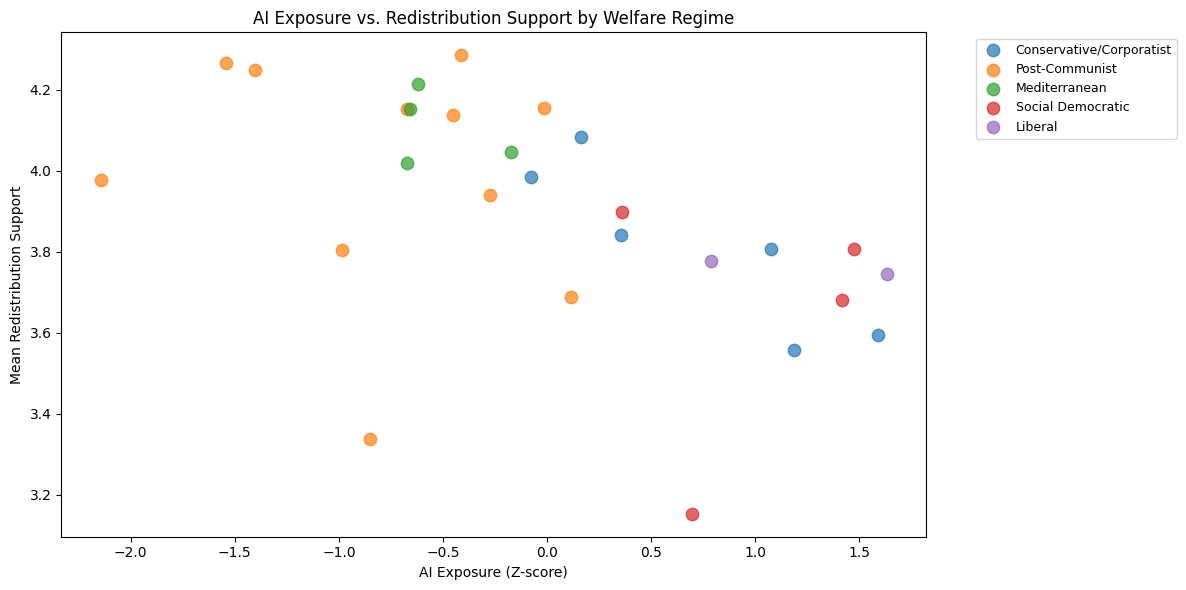

In [14]:
# Visualize AI exposure effects by regime (simple approach)
if has_ai_data:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for regime in country_regime_ai['regime_esping'].unique():
        regime_countries = country_regime_ai[country_regime_ai['regime_esping'] == regime].index
        regime_data = df[df['country'].isin(regime_countries)]
        
        # Country-level means
        country_means = regime_data.groupby('country').agg({
            available_ai_vars[0]: 'first',
            'redist_support': 'mean'
        })
        
        ax.scatter(country_means[available_ai_vars[0]], country_means['redist_support'],
                  label=regime, s=80, alpha=0.7)
    
    ax.set_xlabel('AI Exposure (Z-score)')
    ax.set_ylabel('Mean Redistribution Support')
    ax.set_title('AI Exposure vs. Redistribution Support by Welfare Regime')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(config.PLOTS_DIR / '05_ai_regime_interaction.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Model 16: Social Exposure (AI x Institutions)

Social exposure composite is non-significant (p = 0.857). Even accounting for institutional buffering, AI exposure does not predict redistribution preferences.

In [15]:
has_institutional = 'union_density_z' in df.columns and 'social_spending_z' in df.columns

if has_ai_data and has_institutional and 'social_exposure_z' in df_model.columns:
    # Model 16 with social exposure
    m16_formula = f"redist_support ~ {l1_formula} + {l2_formula} + social_exposure_z"
    m16 = smf.mixedlm(m16_formula, data=df_model, groups=df_model["country"])
    r16 = m16.fit(reml=True)
    print("Model 16: Social Exposure (AI x Institutional Weakness)")
    print(r16.summary())
elif has_ai_data and has_institutional:
    print("Social exposure composite not yet in dataset.")
    print("Creating it now...")
    df_model['social_exposure'] = df_model[available_ai_vars[0]] * (1 - df_model.get('union_density_z', 0))
    se_mean, se_std = df_model['social_exposure'].mean(), df_model['social_exposure'].std()
    if se_std > 0:
        df_model['social_exposure_z'] = (df_model['social_exposure'] - se_mean) / se_std
        m16_formula = f"redist_support ~ {l1_formula} + {l2_formula} + social_exposure_z"
        m16 = smf.mixedlm(m16_formula, data=df_model, groups=df_model["country"])
        r16 = m16.fit(reml=True)
        print(r16.summary())
else:
    print("Insufficient data for social exposure model.")

Social exposure composite not yet in dataset.
Creating it now...


             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  redist_support
No. Observations:  30656    Method:              REML          
No. Groups:        25       Scale:               0.8539        
Min. group size:   468      Log-Likelihood:      -41174.9230   
Max. group size:   2006     Converged:           Yes           
Mean group size:   1226.2                                      
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            3.838    0.047  81.808 0.000  3.746  3.930
income_c            -0.041    0.002 -18.892 0.000 -0.046 -0.037
education_c         -0.009    0.001  -6.266 0.000 -0.012 -0.006
age_c                0.002    0.000   6.546 0.000  0.002  0.003
female               0.082    0.011   7.580 0.000  0.060  0.103
employed             0.021    0.013   1.639 0.101 -0.

## 8. Subgroup Analysis: Who Responds to AI Exposure?

In [16]:
if has_ai_data:
    # Create AI exposure terciles for visualization
    df['ai_tercile'] = pd.qcut(
        df.groupby('country')[available_ai_vars[0]].transform('first'),
        q=3,
        labels=['Low AI Exposure', 'Medium AI Exposure', 'High AI Exposure']
    )
    
    # Redistribution support by AI exposure and education
    edu_col = 'education' if 'education' in df.columns else 'eduyrs'
    if edu_col in df.columns:
        df['education_group'] = pd.cut(
            pd.to_numeric(df[edu_col], errors='coerce'),
            bins=[0, 12, 16, 50],
            labels=['Low', 'Medium', 'High']
        )
        
        ai_education = df.groupby(['ai_tercile', 'education_group'])['redist_support'].mean().unstack()
        
        print("Redistribution support by AI exposure and education:")
        print("="*70)
        print(ai_education.round(2))
    else:
        print("Education variable not found for subgroup analysis")

Redistribution support by AI exposure and education:
education_group      Low  Medium  High
ai_tercile                            
Low AI Exposure     4.09    3.90  3.75
Medium AI Exposure  4.07    3.97  3.79
High AI Exposure    3.71    3.67  3.64


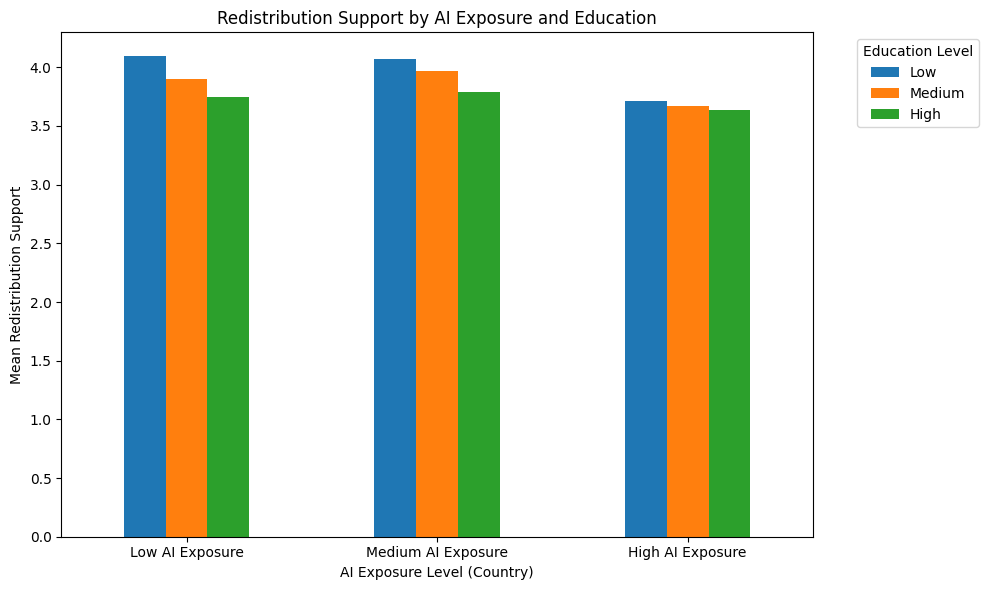

In [17]:
if has_ai_data and 'education_group' in df.columns:
    ai_education.plot(kind='bar', figsize=(10, 6))
    plt.xlabel('AI Exposure Level (Country)')
    plt.ylabel('Mean Redistribution Support')
    plt.title('Redistribution Support by AI Exposure and Education')
    plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(config.PLOTS_DIR / '05_ai_education_interaction.png', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Why the Direct Effect is Null

The Felten AIOE captures cognitive/professional task overlap with AI capabilities, which is highest in wealthy service economies where redistribution demand is already lower. Country-level aggregation may also wash out individual-level threat perceptions. The more empirically grounded pathway runs through AI's downstream effects on income distributions: as AI reshapes who earns what, inequality changes activate the income x Gini interaction (p = 0.002) identified in Notebook 03.

In [ ]:
## 10. Implications for Simulation Design

The null direct effect changes the simulation approach. Instead of modeling AI as a direct attitude driver, the agent-based simulation models AI as an inequality shock that propagates through the empirically estimated income x Gini interaction. The causal chain is: AI labor displacement shifts income distributions, increasing the Gini coefficient, which activates the cross-level interaction and produces nonlinear attitude dynamics across welfare regime types.

## Summary

All three AI exposure specifications return null results: the main effect (M14, p = 0.857), regime interactions (M15, all p > 0.19), and social exposure composite (M16, p = 0.857). The direct pathway from country-level AI exposure to redistribution preferences is not supported. This is informative rather than disappointing -- it rules out the naive technological threat model and redirects attention to the indirect channel through inequality, which has empirical support from the income x Gini interaction (p = 0.002). The Felten AIOE country rankings are substantively meaningful: service economies score highest, reflecting cognitive/professional AI exposure rather than manufacturing automation.

print("Done.")